In [ ]:
!pip install pymssql
import pymssql
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer


In [ ]:
_server = '45.117.83.230'
_port = 1433
_user = 'Student_DA_Q1'
_pass = '@MindXDream2023'
_db = 'DA_FINAL_TEST'

In [ ]:
conn = pymssql.connect(
    host=_server,
    port=_port,
    user=_user,
    password=_pass,
    database=_db
)

In [ ]:
df = pd.read_sql('select * from [dbo].[Customer_Churn_Banker]', conn)
df

/tmp/ipython-input-208-2275454229.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql('select * from [dbo].[Customer_Churn_Banker]', conn)


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


# 1. DISCOVERY DATA


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  object 
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 937.6+ KB


In [ ]:
df.churn.value_counts()

,count
churn,
0,7963
1,2037


In [ ]:
print(df.isnull().sum())

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64


In [ ]:
df.describe(include='all')

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,3,2,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN
top,NaN,NaN,France,Male,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN
freq,NaN,NaN,5014,5457,NaN,NaN,NaN,NaN,7055,NaN,NaN,NaN
mean,1.569094e+07,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,1.530200,NaN,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,0.581654,NaN,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,NaN,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,NaN,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,NaN,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,NaN,1.000000,149388.247500,0.000000


# 2. ANALYZE

In [ ]:
!pip install ydata_profiling
from ydata_profiling import ProfileReport
profile = ProfileReport(df, title="Profiling Report")
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:00<00:00, 14.10it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

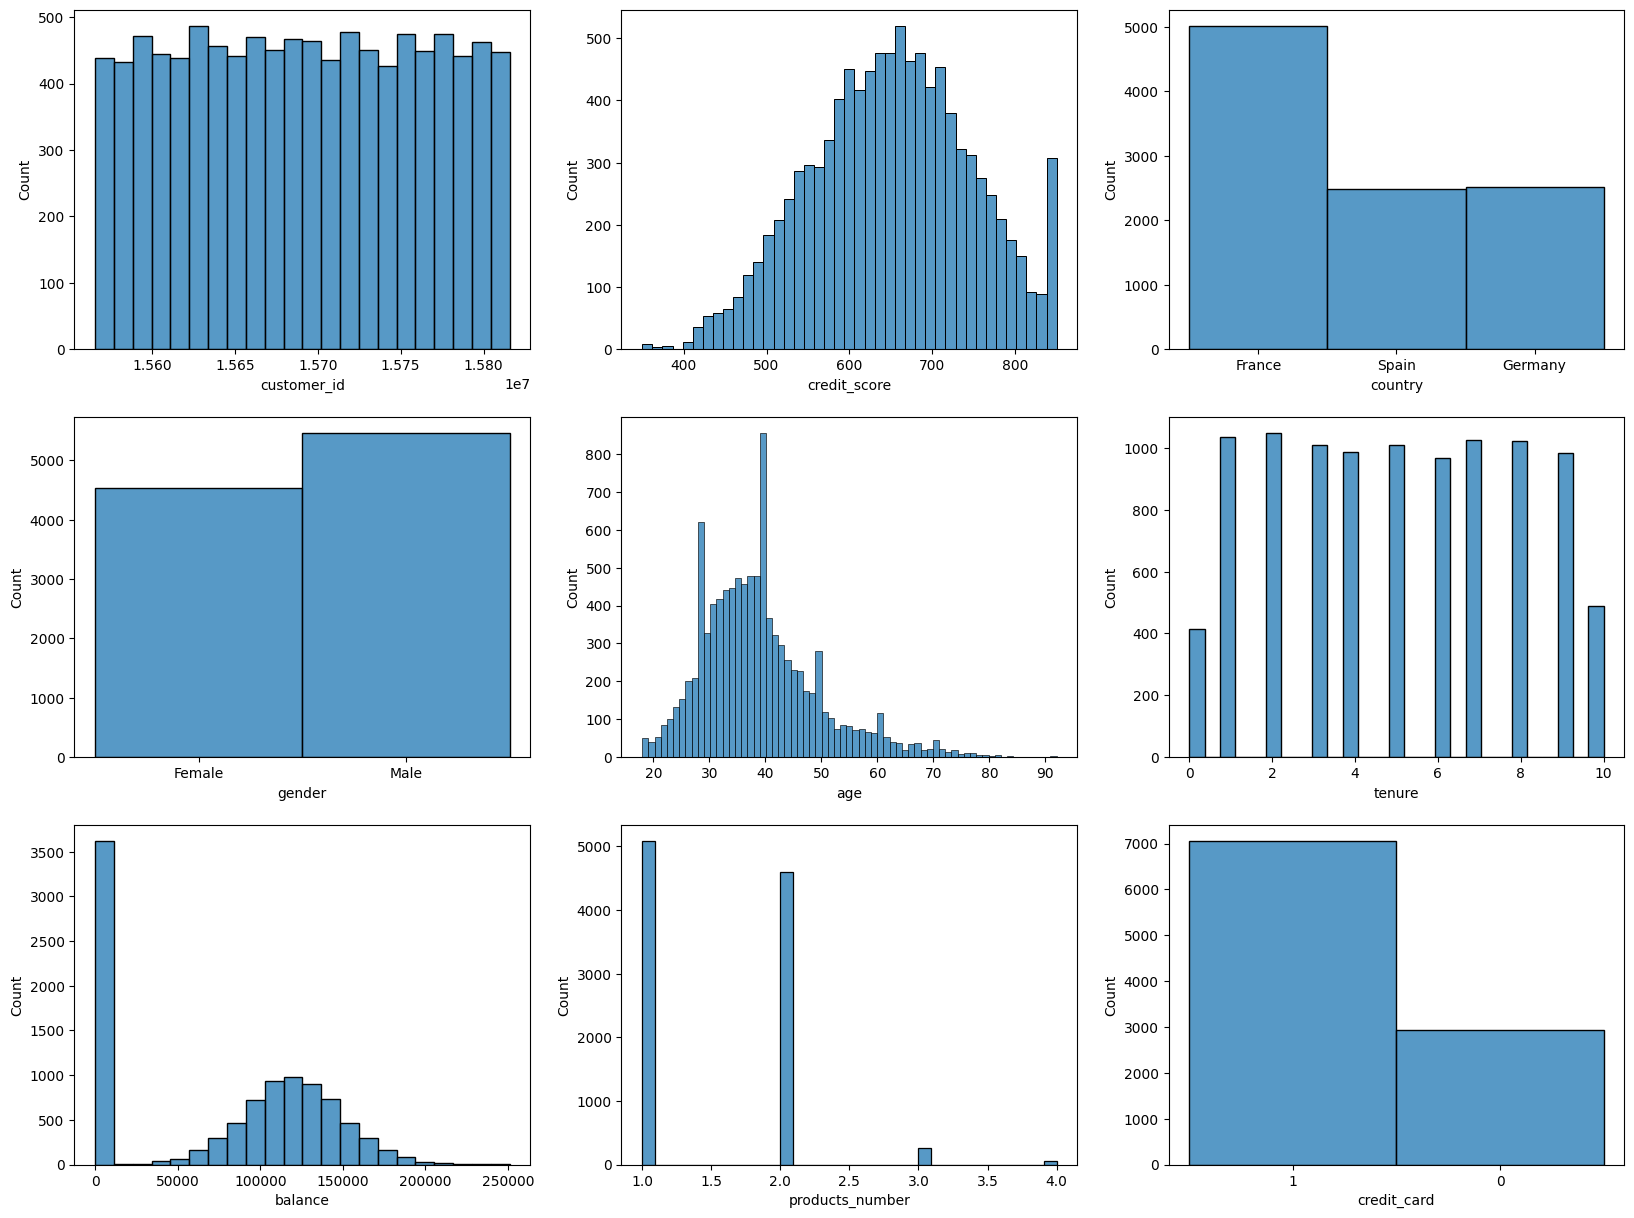

,customer_id,credit_score,age,tenure,balance,products_number,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,199992.480000,1.000000


In [ ]:
fig, axes = plt.subplots(ncols=3, nrows=3, figsize= (20,15))

for col, ax in zip(df, axes.flat):
    sns.histplot(df[col], ax=ax)
plt.show()
df[df.columns].describe()

- credit_score tập trung quanh 600-700
- country thì phân phối không đồng đều, France chiếm 50% khách hàng, Spain và Germany thì ít hơn
- age phần lớn khách hàng nằm trong độ tuổi 30-40, có vài khách hàng rất lớn tuổi (>70)
- balance có nhiều khách hàng có số dư bằng 0 (có thể là không gửi tiền vào tài khoản)

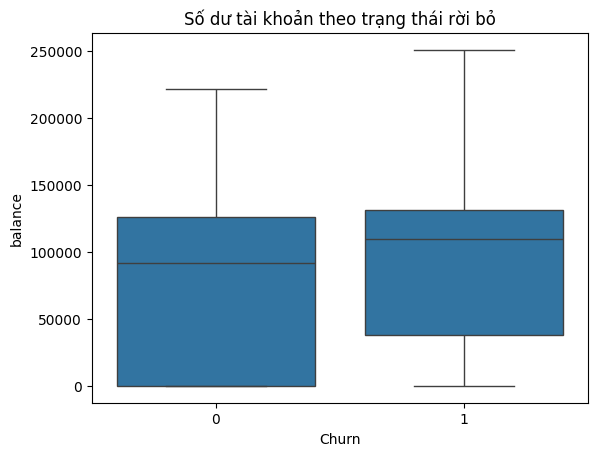

In [ ]:
# phân thích thêm về balance: khách có số dư thấp có rời bỏ không?
sns.boxplot(data=df, x='churn', y='balance')
plt.title('Số dư tài khoản theo trạng thái rời bỏ')
plt.xlabel('Churn')
plt.ylabel('balance')
plt.show()


In [ ]:
df.groupby('churn')['balance'].describe()


,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,7963.0,72745.296779,62848.040701,0.0,0.00,92072.68,126410.28,221532.80
1,2037.0,91108.539337,58360.794816,0.0,38340.02,109349.29,131433.33,250898.09


1. sau khi group by thì có thể thấy khách hàng churn có số dư tài khoản trung bình cao hơn (91k với 72k )
2. boxplot cũng cho thấy nhóm churn = 1 có xu hướng có số dư cao hơn churn = 0.
- không phải khách hàng có số dư thấp sẽ rời bỏ mà ngược lại thì khách có số dư cao có xu hướng rời bỏ nhiều hơn
- có thể thấy rằng khách có số dư cao có thể không hài lòng với lịch vụ của ngân hàng, rời đi dù tiền vẫn còn trong tài khoản
- khách giữ tài khoản nhưng ít dùng hoặc nghỉ goa dịch (balance = 0) vẫn không hẳn là rời bỏ

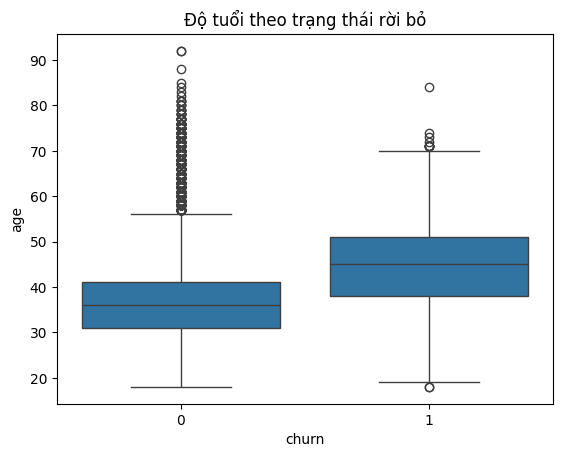

In [ ]:
# mối liên hệ giữa tuổi và churn
sns.boxplot(x='churn', y='age', data=df)
plt.title("Độ tuổi theo trạng thái rời bỏ")
plt.show()

In [ ]:
df.groupby('churn')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,7963.0,37.408389,10.125363,18.0,31.0,36.0,41.0,92.0
1,2037.0,44.837997,9.761562,18.0,38.0,45.0,51.0,84.0


- nhìn vào dữ liệu đã được vẽ phía trên thì có thể thấy khách hàng churn = 1 có độ tuổi trung bình cao hơn đáng kể (~ 45 tuổi) so với churn = 0 ( ~ 37 tuổi)
- có nhiều khách hàng trẻ tuổi ( dưới 30t) ít rời bỏ hơn, trong khi đó tỷ lệ rời bỏ cao hơn với những khách hàng ( trên 40t)

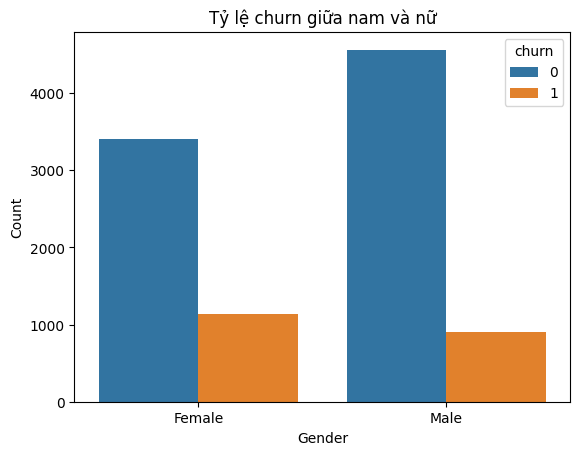

In [ ]:
# So sánh tỷ lệ churn giữa nam và nữ
sns.countplot(data=df, x='gender', hue='churn')
plt.title("Tỷ lệ churn giữa nam và nữ")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()


In [ ]:
churn_by_gender = df.groupby('gender')['churn'].mean()
print(churn_by_gender)


gender
Female    0.250715
Male      0.164559
Name: churn, dtype: float64


- Nhìn vào biểu đồ thì thấy Nữ có tỷ lệ rời bỏ nhiều hơn nam

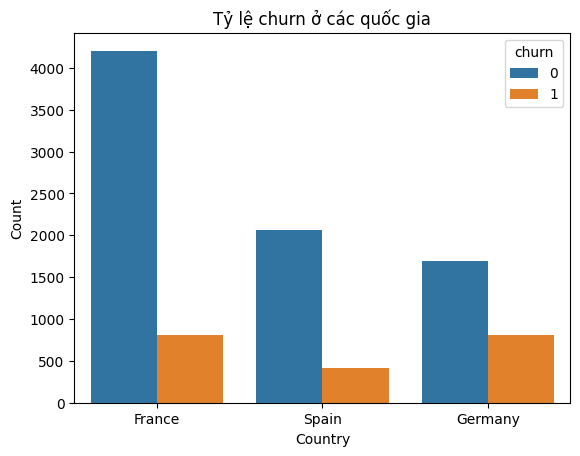

In [ ]:
# So sánh tỷ lệ rời bỏ ở các quốc gia
sns.countplot(data=df, x='country', hue='churn')
plt.title("Tỷ lệ churn ở các quốc gia")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

In [ ]:
df.groupby('country')['churn'].mean().sort_values(ascending=False)


,churn
country,
Germany,0.324432
Spain,0.166734
France,0.161548


- quốc gia có tỷ lệ rời bỏ nhiều nhất là Germany và Spain, France ít rời bỏ nhất.

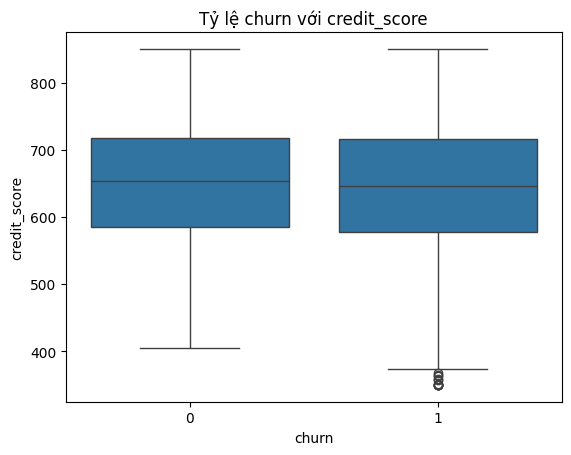

In [ ]:
# So sánh tỷ lệ rời bỏ với khách hàng có credit_score
sns.boxplot(x='churn', y='credit_score', data=df)
plt.title("Tỷ lệ churn với credit_score")
plt.show()

In [ ]:
df.groupby('churn')['credit_score'].describe()


,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,7963.0,651.853196,95.653837,405.0,585.0,653.0,718.0,850.0
1,2037.0,645.351497,100.321503,350.0,578.0,646.0,716.0,850.0


- khách không rời bỏ có mean = 651, cao hơn một chút so với nhóm rời bỏ mean = 645.
- Median cũng tương tự : churn = 0 là 653 và churn = 1 là 646
=> kết luận: Vì chênh lệch giữa churn = 0 và churn = 1 rất nhỏ ( khoảng 6 điểm), không đáng kể nên có thể thấy credit_score chưa ảnh hưởng nhiều đến churn.

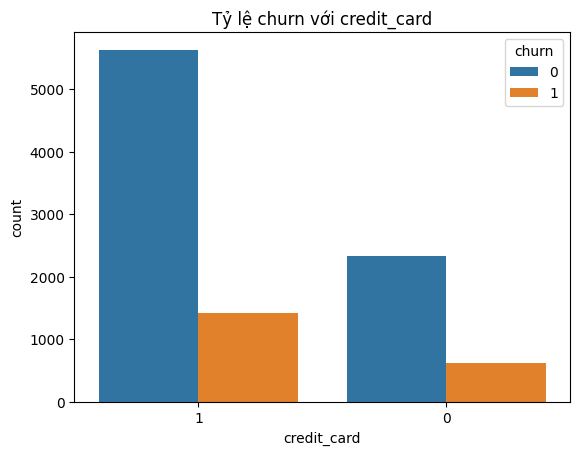

In [ ]:
# Khách có credit_card có rời bỏ không ?
sns.countplot(data=df, x='credit_card', hue='churn')
plt.title("Tỷ lệ churn với credit_card")
plt.show()

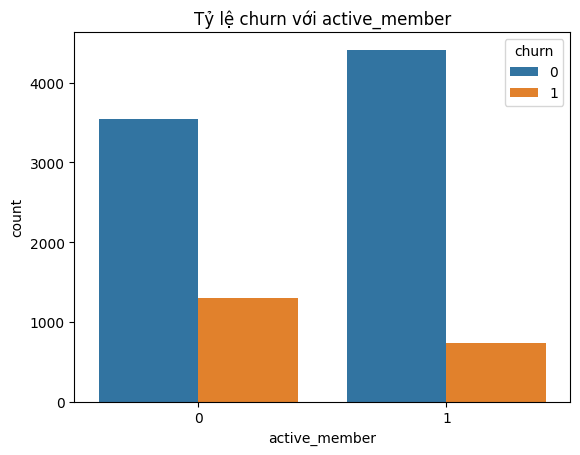

In [ ]:
# Khách không hoạt động churn cao hơn hay ngược lại ?
sns.countplot(data=df, x='active_member', hue='churn')
plt.title("Tỷ lệ churn với active_member")
plt.show()

- Khách hàng không hoạt động có tỷ lệ churn cao hơn -> cần xem xét và chăm sóc, nhắc nhở hoạt động của khách hàng

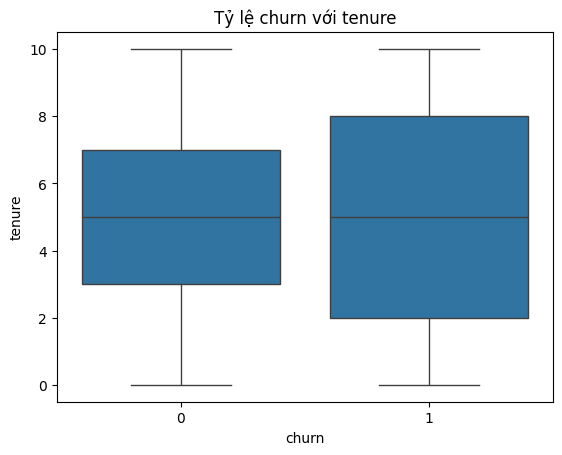

In [ ]:
# Tenure có ảnh hưởng gì đến churn không?
sns.boxplot(x='churn', y='tenure', data=df)
plt.title("Tỷ lệ churn với tenure")
plt.show()

In [ ]:
df.groupby('churn')['tenure'].describe()


,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,7963.0,5.033279,2.880658,0.0,3.0,5.0,7.0,10.0
1,2037.0,4.932744,2.936106,0.0,2.0,5.0,8.0,10.0


- Mean của churn = 0 và churn = 1 không thấy chệnh lệch nhiều và quá rõ, median bằng nhau -> Khổng ảnh hưởng mạnh đến churn.

# 3. MODEL PREDICTION

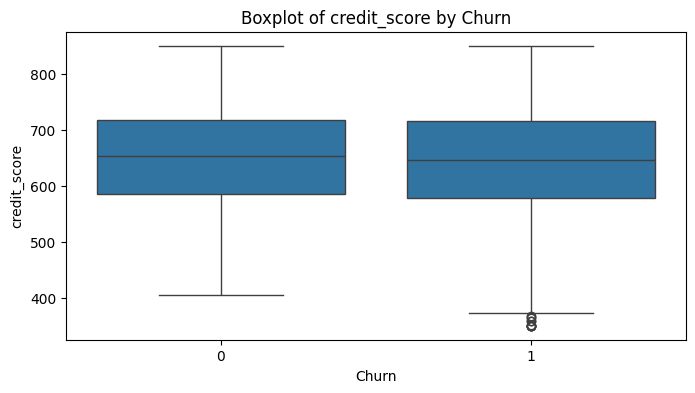

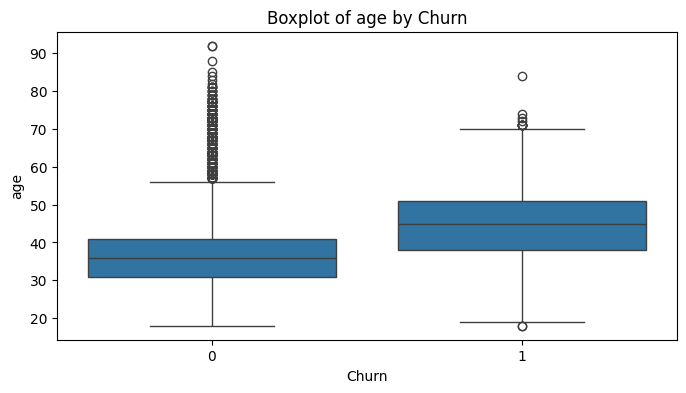

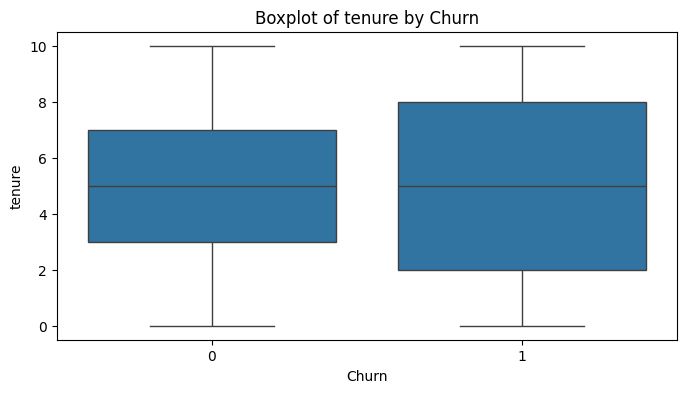

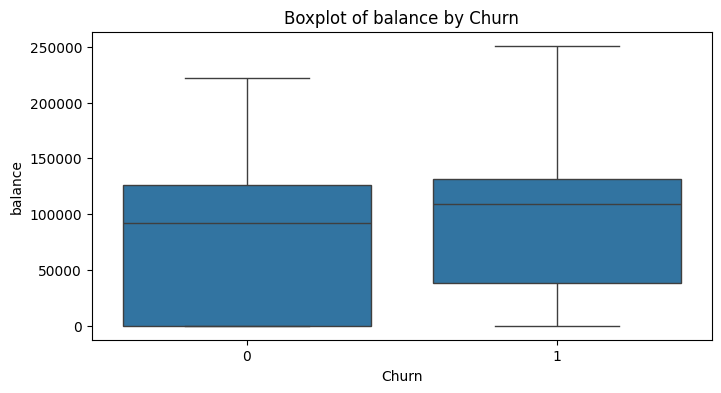

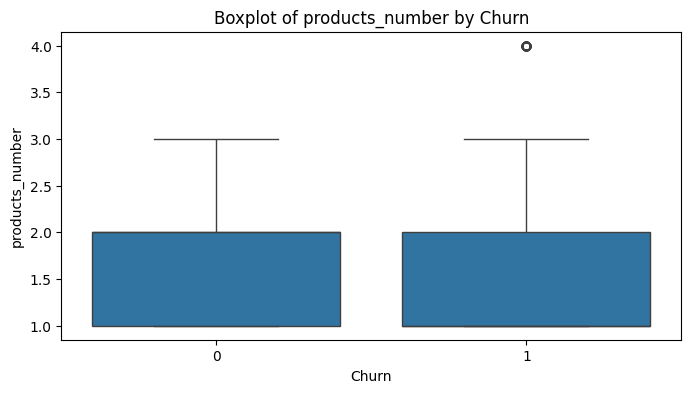

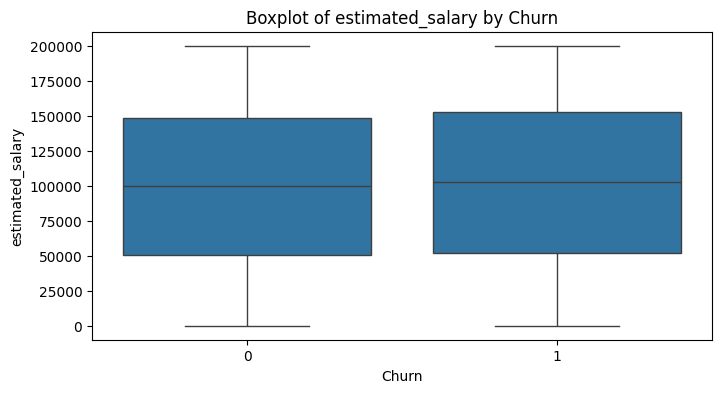

In [ ]:
# kiểm tra outlier by churn
num_cols = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']


for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x='churn', y=col)
    plt.title(f"Boxplot of {col} by Churn")
    plt.xlabel("Churn")
    plt.ylabel(col)
    plt.show()

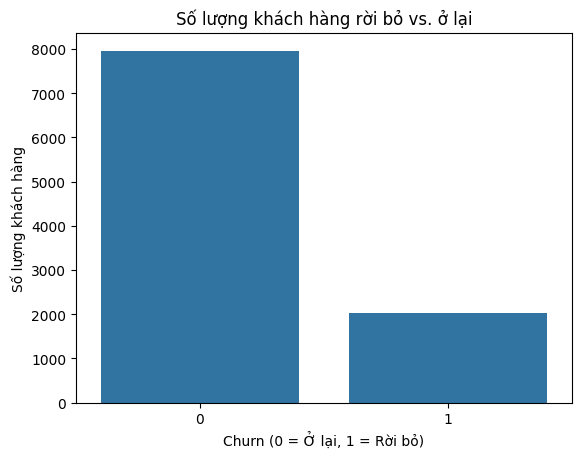

In [ ]:
sns.countplot(data=df, x='churn')
plt.title("Số lượng khách hàng rời bỏ vs. ở lại")
plt.xlabel("Churn (0 = Ở lại, 1 = Rời bỏ)")
plt.ylabel("Số lượng khách hàng")
plt.show()

In [ ]:
df.churn.value_counts()

,count
churn,
0,7963
1,2037


- data bị imbalance ở churn, tỷ lệ giữa ở lại và rời bỏ chênh lệch nhau 7963/2037.

In [ ]:
X

,customer_id,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_France,country_Germany,country_Spain
0,-0.783213,-0.326878,-1.095988,0.342615,-1.041760,-1.225848,-0.924827,0.646092,0.970243,0.021886,1.977165,0.997204,-0.578736,-0.573809
1,-0.606534,-0.440804,-1.095988,0.240011,-1.387538,0.117350,-0.924827,-1.547768,0.970243,0.216534,-0.505775,-1.002804,-0.578736,1.742740
2,-0.995885,-1.538636,-1.095988,0.342615,1.032908,1.333053,2.583620,0.646092,-1.030670,0.240687,1.977165,0.997204,-0.578736,-0.573809
3,0.144767,0.501675,-1.095988,0.034803,-1.387538,-1.225848,0.829397,-1.547768,-1.030670,-0.108918,-0.505775,0.997204,-0.578736,-0.573809
4,0.652659,2.065569,-1.095988,0.445219,-1.041760,0.785728,-0.924827,0.646092,0.970243,-0.365276,-0.505775,-1.002804,-0.578736,1.742740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,-1.177652,1.247373,0.912419,0.034803,-0.004426,-1.225848,0.829397,0.646092,-1.030670,-0.066419,-0.505775,0.997204,-0.578736,-0.573809
9996,-1.682806,-1.393640,0.912419,-0.375612,1.724464,-0.306379,-0.924827,0.646092,0.970243,0.027988,-0.505775,0.997204,-0.578736,-0.573809
9997,-1.479282,0.605244,-1.095988,-0.273008,0.687130,-1.225848,-0.924827,-1.547768,0.970243,-1.008643,1.977165,0.997204,-0.578736,-0.573809
9998,-0.119356,1.257730,0.912419,0.342615,-0.695982,-0.022608,0.829397,0.646092,-1.030670,-0.125231,1.977165,-1.002804,1.727904,-0.573809


In [ ]:
y

,churn
0,1
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,1


In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [ ]:
# preprocessing
X = df.drop(columns='churn').reset_index(drop=True)
y = df.churn

In [ ]:
# Label encode gender
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})


In [ ]:
# 1HEncoder cột country
_enc = OneHotEncoder(sparse_output=False)
_enc.fit(X[['country']])
_transformed = pd.DataFrame(_enc.transform(X[['country']]), columns=_enc.get_feature_names_out())

# concat
X.drop(columns='country', inplace=True)
X = pd.concat([X, _transformed], axis=1)


In [ ]:
X

,customer_id,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_France,country_Germany,country_Spain
0,15634602,619,0,42,2,0.00,1.0,1,1,101348.88,1,1.0,0.0,0.0
1,15647311,608,0,41,1,83807.86,1.0,0,1,112542.58,0,0.0,0.0,1.0
2,15619304,502,0,42,8,159660.80,3.0,1,0,113931.57,1,1.0,0.0,0.0
3,15701354,699,0,39,1,0.00,2.0,0,0,93826.63,0,1.0,0.0,0.0
4,15737888,850,0,43,2,125510.82,1.0,1,1,79084.10,0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,1,39,5,0.00,2.0,1,0,96270.64,0,1.0,0.0,0.0
9996,15569892,516,1,35,10,57369.61,1.0,1,1,101699.77,0,1.0,0.0,0.0
9997,15584532,709,0,36,7,0.00,1.0,0,1,42085.58,1,1.0,0.0,0.0
9998,15682355,772,1,42,3,75075.31,2.0,1,0,92888.52,1,0.0,1.0,0.0


In [ ]:
X.drop(columns=['customer_id'], inplace=True) # drop cột customer_id vì không cần thiết


In [ ]:
X

,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,country_France,country_Germany,country_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1.0,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0.0,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1.0,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,1.0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,1,39,5,0.00,2,1,0,96270.64,1.0,0.0,0.0
9996,516,1,35,10,57369.61,1,1,1,101699.77,1.0,0.0,0.0
9997,709,0,36,7,0.00,1,0,1,42085.58,1.0,0.0,0.0
9998,772,1,42,3,75075.31,2,1,0,92888.52,0.0,1.0,0.0


In [ ]:
# scaler
_scaler = StandardScaler()
_scaler.fit(X)
X = pd.DataFrame(_scaler.transform(X), columns=X.columns)



In [ ]:
X

,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,country_France,country_Germany,country_Spain
0,-0.326221,-1.095988,0.293517,-1.041760,-1.225848,-0.911583,0.646092,0.970243,0.021886,0.997204,-0.578736,-0.573809
1,-0.440036,-1.095988,0.198164,-1.387538,0.117350,-0.911583,-1.547768,0.970243,0.216534,-1.002804,-0.578736,1.742740
2,-1.536794,-1.095988,0.293517,1.032908,1.333053,2.527057,0.646092,-1.030670,0.240687,0.997204,-0.578736,-0.573809
3,0.501521,-1.095988,0.007457,-1.387538,-1.225848,0.807737,-1.547768,-1.030670,-0.108918,0.997204,-0.578736,-0.573809
4,2.063884,-1.095988,0.388871,-1.041760,0.785728,-0.911583,0.646092,0.970243,-0.365276,-1.002804,-0.578736,1.742740
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1.246488,0.912419,0.007457,-0.004426,-1.225848,0.807737,0.646092,-1.030670,-0.066419,0.997204,-0.578736,-0.573809
9996,-1.391939,0.912419,-0.373958,1.724464,-0.306379,-0.911583,0.646092,0.970243,0.027988,0.997204,-0.578736,-0.573809
9997,0.604988,-1.095988,-0.278604,0.687130,-1.225848,-0.911583,-1.547768,0.970243,-1.008643,0.997204,-0.578736,-0.573809
9998,1.256835,0.912419,0.293517,-0.695982,-0.022608,0.807737,0.646092,-1.030670,-0.125231,-1.002804,1.727904,-0.573809


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, recall_score
from sklearn.linear_model import LogisticRegression

In [ ]:
!pip install imblearn
from imblearn.over_sampling import SMOTE

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3)

In [ ]:
_imb = SMOTE()
X_train_resample, y_train_resample = _imb.fit_resample(X_train, y_train)

In [ ]:
y_train.value_counts()

,count
churn,
0,5566
1,1434


In [ ]:
y_train_resample.value_counts()

,count
churn,
0,5566
1,5566


In [ ]:
print(X.columns)


Index(['customer_id', 'credit_score', 'gender', 'age', 'tenure', 'balance',
       'products_number', 'credit_card', 'active_member', 'estimated_salary',
       'churn', 'country_France', 'country_Germany', 'country_Spain'],
      dtype='object')


              precision    recall  f1-score   support

           0       0.83      0.96      0.89      2397
           1       0.54      0.20      0.29       603

    accuracy                           0.80      3000
   macro avg       0.68      0.58      0.59      3000
weighted avg       0.77      0.80      0.77      3000



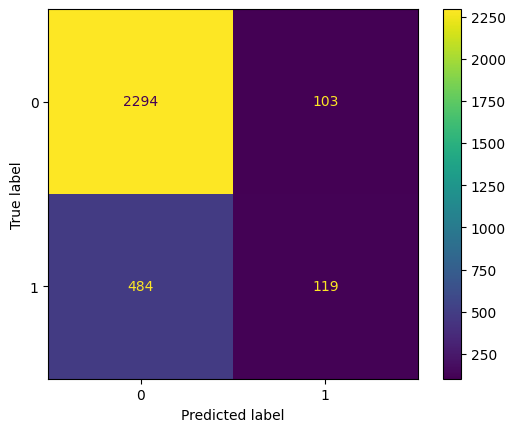

In [ ]:
# thử mô hình logistic với no resampling
_model = LogisticRegression()
_model.fit(X_train, y_train)
y_pred = _model.predict(X_test)

print(classification_report(y_true=y_test, y_pred=y_pred))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=y_pred)

              precision    recall  f1-score   support

           0       0.88      0.94      0.91      2397
           1       0.68      0.47      0.55       603

    accuracy                           0.85      3000
   macro avg       0.78      0.71      0.73      3000
weighted avg       0.84      0.85      0.84      3000



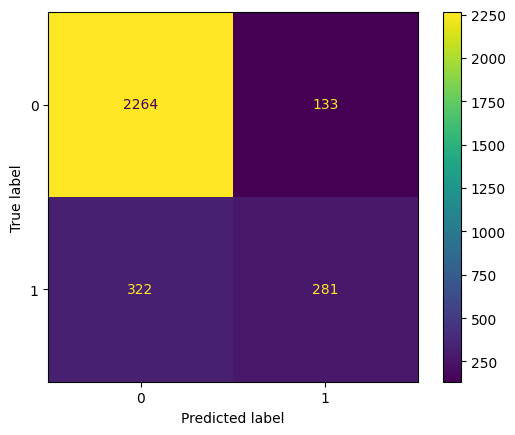

In [ ]:
# thử mô hình XGBClassifier với no resampling
from xgboost import XGBClassifier
_model = XGBClassifier()
_model.fit(X_train, y_train)
y_pred = _model.predict(X_test)

print(classification_report(y_true=y_test, y_pred=y_pred))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=y_pred)

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      2397
           1       0.77      0.45      0.56       603

    accuracy                           0.86      3000
   macro avg       0.82      0.71      0.74      3000
weighted avg       0.85      0.86      0.85      3000



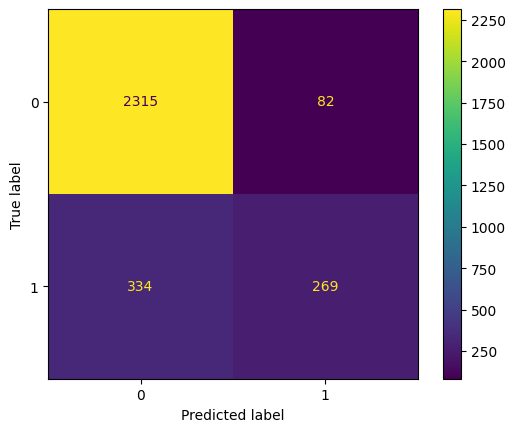

In [ ]:
# thử mô hình RandomForest với no resampling
from sklearn.ensemble import RandomForestClassifier
_model = RandomForestClassifier()
_model.fit(X_train, y_train)
y_pred = _model.predict(X_test)

print(classification_report(y_true=y_test, y_pred=y_pred))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=y_pred)

              precision    recall  f1-score   support

           0       0.88      0.88      0.88      2397
           1       0.51      0.52      0.52       603

    accuracy                           0.80      3000
   macro avg       0.70      0.70      0.70      3000
weighted avg       0.81      0.80      0.81      3000



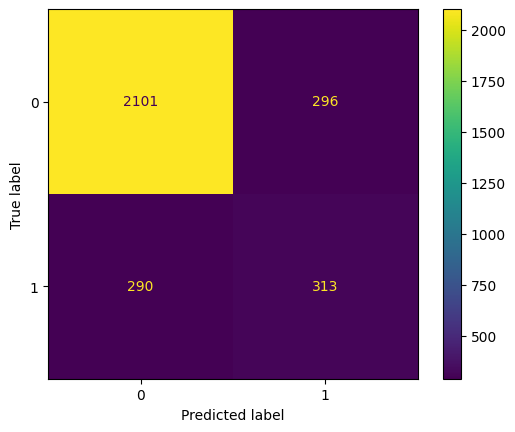

In [ ]:
# thử mô hình DecisionTree với no resampling
from sklearn.tree import DecisionTreeClassifier
_model = DecisionTreeClassifier()
_model.fit(X_train, y_train)
y_pred = _model.predict(X_test)

print(classification_report(y_true=y_test, y_pred=y_pred))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=y_pred)

              precision    recall  f1-score   support

           0       0.90      0.71      0.79      2397
           1       0.37      0.69      0.48       603

    accuracy                           0.70      3000
   macro avg       0.64      0.70      0.64      3000
weighted avg       0.79      0.70      0.73      3000



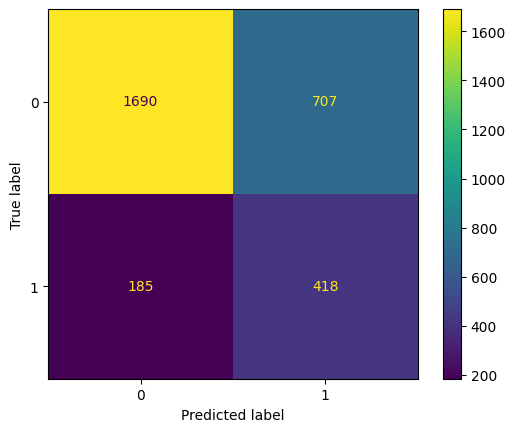

In [ ]:
# thử mô hình logisticRegression (oversampling)
_model = LogisticRegression()
_model.fit(X_train_resample, y_train_resample)
y_pred = _model.predict(X_test)

print(classification_report(y_true=y_test, y_pred=y_pred))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=y_pred)

              precision    recall  f1-score   support

           0       0.89      0.93      0.91      2397
           1       0.68      0.56      0.62       603

    accuracy                           0.86      3000
   macro avg       0.79      0.75      0.77      3000
weighted avg       0.85      0.86      0.85      3000



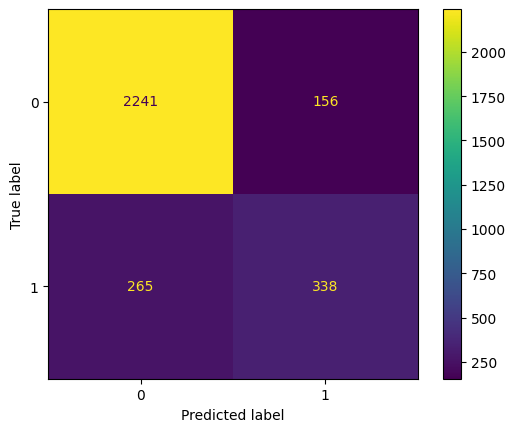

In [ ]:
# oversampling mô hình XGBClassifier
from xgboost import XGBClassifier
_model = XGBClassifier()
_model.fit(X_train_resample, y_train_resample)
y_pred = _model.predict(X_test)

print(classification_report(y_true=y_test, y_pred=y_pred))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=y_pred)

              precision    recall  f1-score   support

           0       0.90      0.90      0.90      2397
           1       0.60      0.58      0.59       603

    accuracy                           0.84      3000
   macro avg       0.75      0.74      0.74      3000
weighted avg       0.84      0.84      0.84      3000



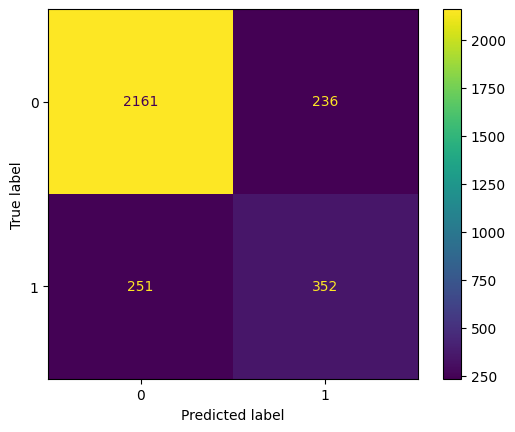

In [ ]:
# thử mô hình RandomForest với oversampling
from sklearn.ensemble import RandomForestClassifier
_model = RandomForestClassifier()
_model.fit(X_train_resample, y_train_resample)
y_pred = _model.predict(X_test)

print(classification_report(y_true=y_test, y_pred=y_pred))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=y_pred)

              precision    recall  f1-score   support

           0       0.88      0.83      0.85      2397
           1       0.44      0.54      0.49       603

    accuracy                           0.77      3000
   macro avg       0.66      0.69      0.67      3000
weighted avg       0.79      0.77      0.78      3000



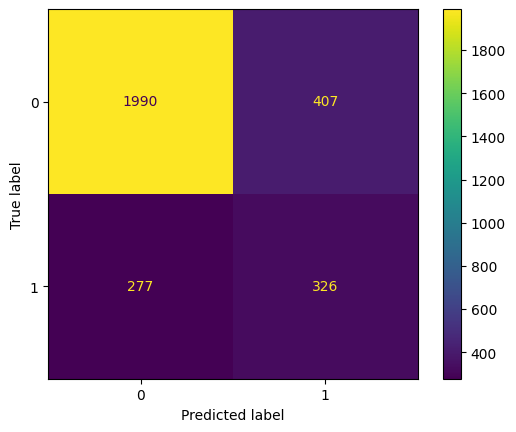

In [ ]:
# thử mô hình DecissionTree với oversampling
from sklearn.tree import DecisionTreeClassifier
_model = DecisionTreeClassifier()
_model.fit(X_train_resample, y_train_resample)
y_pred = _model.predict(X_test)

print(classification_report(y_true=y_test, y_pred=y_pred))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=y_pred)